In [ ]:
# import libraries needed in work book
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Will work on dynamically setting filepath soon
file_path = "csv\cleaned_csv\pp-test-1000prems_cleaned_data.csv"

df = pd.read_csv(file_path, index_col=0)
# clean up date
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'], errors='coerce') # turn date into datetime value

In [181]:
# Add a Year Col, then using the year col add an year average price column
average_type = 'mean'
df['year_of_transfer'] = df['date_of_transfer'].dt.year # add a column with just the year for agg purposes. dt.year gives me an int. dt.strftime('%Y') gives a string
df['year_avg_sale'] = df.groupby('year_of_transfer')['price'].transform(average_type)

average_type = average_type.capitalize() # for the title of the graph

In [182]:
df_plot = df.copy()

In [183]:
df_plot = df_plot.sort_values('year_of_transfer')

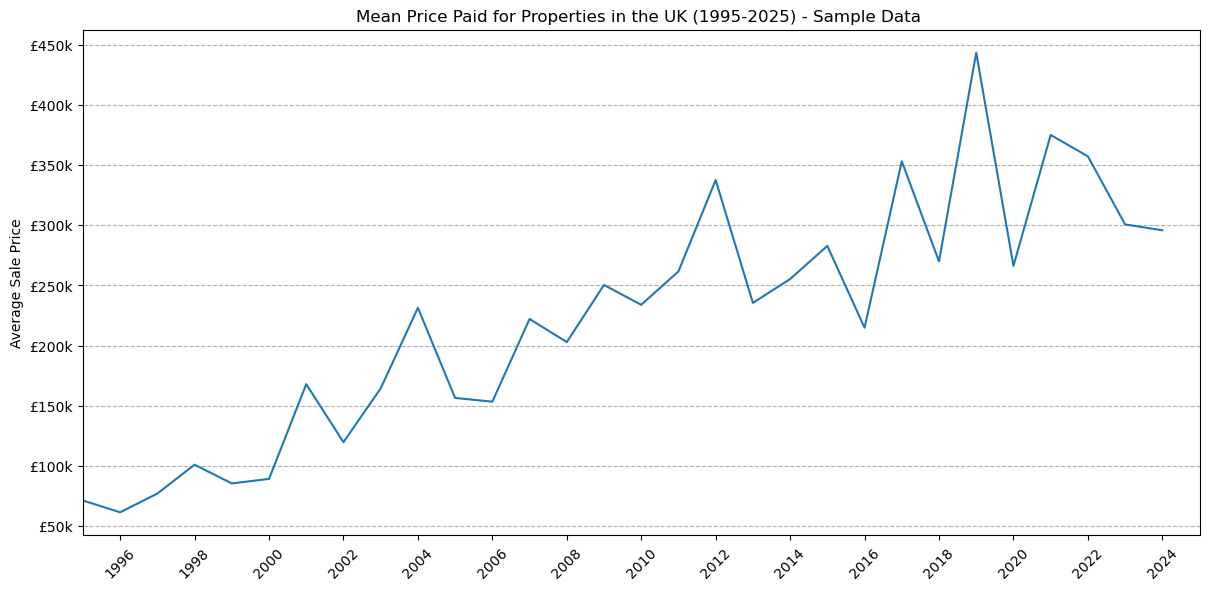

In [ ]:
fig, ax = plt.subplots()

df_plot.plot(kind='line', x='year_of_transfer', y='year_avg_sale', figsize=(12,6), ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'£{int(y/1000)}k'))
plt.locator_params(axis='x', nbins=19) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle="--")
plt.xlim(1995, 2025)
plt.legend().set_visible(False)
plt.xlabel('')
plt.ylabel('Average Sale Price')
plt.title(f'{average_type} Price Paid for Properties in the UK (1995-2025) - Sample Data ')

plt.show()
